100%|██████████| 9.91M/9.91M [00:03<00:00, 2.51MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.53MB/s]


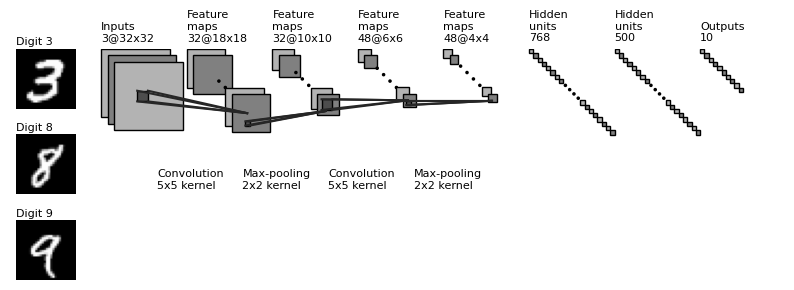

In [ ]:
"""
Extended version of Gavin Ding's CNN diagram generator.
Adds MNIST sample digits (3, 8, 9) automatically and saves final figure.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcdefaults()
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Circle

# ---- NEW: MNIST imports ----
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# ---- Constants ----
NumDots = 4
NumConvMax = 8
NumFcMax = 20
White = 1.
Light = 0.7
Medium = 0.5
Dark = 0.3
Darker = 0.15
Black = 0.


# ------------------------------
# Original helper functions
# ------------------------------

def add_layer(patches, colors, size=(24, 24), num=5,
              top_left=[0, 0], loc_diff=[3, -3]):
    top_left = np.array(top_left)
    loc_diff = np.array(loc_diff)
    loc_start = top_left - np.array([0, size[0]])
    for ind in range(num):
        patches.append(Rectangle(loc_start + ind * loc_diff, size[1], size[0]))
        colors.append(Medium if ind % 2 else Light)


def add_layer_with_omission(patches, colors, size=(24, 24),
                            num=5, num_max=8, num_dots=4,
                            top_left=[0, 0], loc_diff=[3, -3]):
    top_left = np.array(top_left)
    loc_diff = np.array(loc_diff)
    loc_start = top_left - np.array([0, size[0]])
    this_num = min(num, num_max)
    start_omit = (this_num - num_dots) // 2 - 1
    end_omit = this_num - (this_num - num_dots) // 2

    for ind in range(this_num):
        omit = (num > num_max) and (start_omit < ind < end_omit)
        if omit:
            patches.append(Circle(loc_start + ind * loc_diff + np.array(size) / 2, 0.5))
            colors.append(Black)
        else:
            patches.append(Rectangle(loc_start + ind * loc_diff, size[1], size[0]))
            colors.append(Medium if ind % 2 else Light)


def add_mapping(patches, colors, start_ratio, end_ratio, patch_size, ind_bgn,
                top_left_list, loc_diff_list, num_show_list, size_list):

    start_loc = top_left_list[ind_bgn] \
        + (num_show_list[ind_bgn] - 1) * np.array(loc_diff_list[ind_bgn]) \
        + np.array([start_ratio[0] * (size_list[ind_bgn][1] - patch_size[1]),
                    -start_ratio[1] * (size_list[ind_bgn][0] - patch_size[0])])

    end_loc = top_left_list[ind_bgn + 1] \
        + (num_show_list[ind_bgn + 1] - 1) * np.array(loc_diff_list[ind_bgn + 1]) \
        + np.array([end_ratio[0] * size_list[ind_bgn + 1][1],
                    -end_ratio[1] * size_list[ind_bgn + 1][0]])

    patches.append(Rectangle(start_loc, patch_size[1], -patch_size[0]))
    colors.append(Dark)

    for dx in [0, patch_size[1]]:
        for dy in [0, -patch_size[0]]:
            patches.append(Line2D([start_loc[0] + dx, end_loc[0]],
                                  [start_loc[1] + dy, end_loc[1]]))
            colors.append(Darker)


def label(xy, text, xy_off=[0, 4]):
    plt.text(xy[0] + xy_off[0], xy[1] + xy_off[1], text,
             family='sans-serif', size=8)


# ------------------------------
# NEW: Load MNIST digits 3, 8, 9
# ------------------------------

def load_mnist_digits():
    mnist = datasets.MNIST(root=".", train=True, download=True,
                           transform=transforms.ToTensor())
    digits = {3: None, 8: None, 9: None}

    for img, label in mnist:
        if label in digits and digits[label] is None:
            digits[label] = img.squeeze(0).numpy()
        if all(v is not None for v in digits.values()):
            break

    return digits


# ------------------------------
# Main drawing logic
# ------------------------------

if __name__ == '__main__':

    # Load MNIST digits
    digits = load_mnist_digits()

    fc_unit_size = 2
    layer_width = 40
    flag_omit = True

    patches = []
    colors = []

    fig, ax = plt.subplots(figsize=(10, 3))

    # ------------------------------
    # Draw MNIST digits on the left
    # ------------------------------
    y_positions = [0, -40, -80]  # vertical spacing
    for (digit, img), y in zip(digits.items(), y_positions):
        ax.imshow(img, cmap="gray", extent=[-40, -12, y - 28, y])
        plt.text(-40, y + 2, f"Digit {digit}", fontsize=8)

    # ------------------------------
    # CNN layers (original code)
    # ------------------------------
    size_list = [(32, 32), (18, 18), (10, 10), (6, 6), (4, 4)]
    num_list = [3, 32, 32, 48, 48]
    x_diff_list = [0, layer_width, layer_width, layer_width, layer_width]
    text_list = ['Inputs'] + ['Feature\nmaps'] * (len(size_list) - 1)
    loc_diff_list = [[3, -3]] * len(size_list)

    num_show_list = list(map(min, num_list, [NumConvMax] * len(num_list)))
    top_left_list = np.c_[np.cumsum(x_diff_list), np.zeros(len(x_diff_list))]

    for ind in range(len(size_list)-1, -1, -1):
        if flag_omit:
            add_layer_with_omission(patches, colors, size=size_list[ind],
                                    num=num_list[ind], num_max=NumConvMax,
                                    num_dots=NumDots,
                                    top_left=top_left_list[ind],
                                    loc_diff=loc_diff_list[ind])
        else:
            add_layer(patches, colors, size=size_list[ind],
                      num=num_show_list[ind],
                      top_left=top_left_list[ind],
                      loc_diff=loc_diff_list[ind])

        label(top_left_list[ind],
              text_list[ind] + '\n{}@{}x{}'.format(
                  num_list[ind], size_list[ind][0], size_list[ind][1]))

    # ------------------------------
    # Connections between conv layers
    # ------------------------------
    start_ratio_list = [[0.4, 0.5], [0.4, 0.8], [0.4, 0.5], [0.4, 0.8]]
    end_ratio_list = [[0.4, 0.5], [0.4, 0.8], [0.4, 0.5], [0.4, 0.8]]
    patch_size_list = [(5, 5), (2, 2), (5, 5), (2, 2)]
    text_list = ['Convolution', 'Max-pooling', 'Convolution', 'Max-pooling']

    for ind in range(len(patch_size_list)):
        add_mapping(patches, colors, start_ratio_list[ind],
                    end_ratio_list[ind], patch_size_list[ind], ind,
                    top_left_list, loc_diff_list, num_show_list, size_list)

        label(top_left_list[ind],
              text_list[ind] + '\n{}x{} kernel'.format(
                  patch_size_list[ind][0], patch_size_list[ind][1]),
              xy_off=[26, -65])

    # ------------------------------
    # Fully connected layers
    # ------------------------------
    size_list = [(fc_unit_size, fc_unit_size)] * 3
    num_list = [768, 500, 10]  # final layer = 10 classes
    num_show_list = list(map(min, num_list, [NumFcMax] * len(num_list)))
    x_diff_list = [sum(x_diff_list) + layer_width, layer_width, layer_width]
    top_left_list = np.c_[np.cumsum(x_diff_list), np.zeros(len(x_diff_list))]
    loc_diff_list = [[fc_unit_size, -fc_unit_size]] * len(top_left_list)
    text_list = ['Hidden\nunits', 'Hidden\nunits', 'Outputs']

    for ind in range(len(size_list)):
        add_layer_with_omission(patches, colors, size=size_list[ind],
                                num=num_list[ind], num_max=NumFcMax,
                                num_dots=NumDots,
                                top_left=top_left_list[ind],
                                loc_diff=loc_diff_list[ind])

        label(top_left_list[ind], text_list[ind] + '\n{}'.format(num_list[ind]))

    # ------------------------------
    # Render patches
    # ------------------------------
    for patch, color in zip(patches, colors):
        patch.set_color(color * np.ones(3))
        if isinstance(patch, Line2D):
            ax.add_line(patch)
        else:
            patch.set_edgecolor(Black * np.ones(3))
            ax.add_patch(patch)

    plt.axis('equal')
    plt.axis('off')

    # ------------------------------
    # Save final figure
    # ------------------------------
    fig.savefig("../M03_lecture02_figures/convnet_mnist.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()


In [3]:
"""
MNIST CNN Architecture Diagram Generator (Option B)
Based on Gavin Ding's original convnet figure script.
Extended to:
 - load MNIST automatically
 - embed digit images (0–9)
 - draw modern CNN architecture (Conv-Conv-Pool-Conv-Conv-Pool-FC)
 - color-code input, conv, fc, output layers
 - save 10 diagrams (one per digit)
"""

import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcdefaults()

from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Circle

# ---- NEW: MNIST imports ----
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# ---- Colors ----
COLOR_INPUT = np.array([0.2, 0.4, 1.0])     # blue
COLOR_CONV  = np.array([0.2, 0.8, 0.4])     # green
COLOR_FC    = np.array([1.0, 0.6, 0.2])     # orange
COLOR_OUT   = np.array([1.0, 0.2, 0.2])     # red
COLOR_DOT   = np.array([0.0, 0.0, 0.0])     # black

NumDots = 4
NumConvMax = 8
NumFcMax = 20


# ------------------------------
# Helper functions
# ------------------------------

def add_layer(patches, colors, size=(24, 24), num=5,
              top_left=[0, 0], loc_diff=[3, -3], color=COLOR_CONV):
    top_left = np.array(top_left)
    loc_diff = np.array(loc_diff)
    loc_start = top_left - np.array([0, size[0]])
    for ind in range(num):
        patches.append(Rectangle(loc_start + ind * loc_diff, size[1], size[0]))
        colors.append(color)


def add_layer_with_omission(patches, colors, size=(24, 24),
                            num=5, num_max=8, num_dots=4,
                            top_left=[0, 0], loc_diff=[3, -3],
                            color=COLOR_CONV):
    top_left = np.array(top_left)
    loc_diff = np.array(loc_diff)
    loc_start = top_left - np.array([0, size[0]])
    this_num = min(num, num_max)
    start_omit = (this_num - num_dots) // 2 - 1
    end_omit = this_num - (this_num - num_dots) // 2

    for ind in range(this_num):
        omit = (num > num_max) and (start_omit < ind < end_omit)
        if omit:
            patches.append(Circle(loc_start + ind * loc_diff + np.array(size) / 2, 0.5))
            colors.append(COLOR_DOT)
        else:
            patches.append(Rectangle(loc_start + ind * loc_diff, size[1], size[0]))
            colors.append(color)


def add_mapping(patches, colors, start_ratio, end_ratio, patch_size, ind_bgn,
                top_left_list, loc_diff_list, num_show_list, size_list,
                color=COLOR_CONV):

    start_loc = top_left_list[ind_bgn] \
        + (num_show_list[ind_bgn] - 1) * np.array(loc_diff_list[ind_bgn]) \
        + np.array([start_ratio[0] * (size_list[ind_bgn][1] - patch_size[1]),
                    -start_ratio[1] * (size_list[ind_bgn][0] - patch_size[0])])

    end_loc = top_left_list[ind_bgn + 1] \
        + (num_show_list[ind_bgn + 1] - 1) * np.array(loc_diff_list[ind_bgn + 1]) \
        + np.array([end_ratio[0] * size_list[ind_bgn + 1][1],
                    -end_ratio[1] * size_list[ind_bgn + 1][0]])

    patches.append(Rectangle(start_loc, patch_size[1], -patch_size[0]))
    colors.append(color * 0.6)

    for dx in [0, patch_size[1]]:
        for dy in [0, -patch_size[0]]:
            patches.append(Line2D([start_loc[0] + dx, end_loc[0]],
                                  [start_loc[1] + dy, end_loc[1]]))
            colors.append(color * 0.3)


def label(xy, text, xy_off=[0, 4]):
    plt.text(xy[0] + xy_off[0], xy[1] + xy_off[1], text,
             family='sans-serif', size=8)


# ------------------------------
# Load MNIST digits 0–9
# ------------------------------

def load_mnist_digits():
    mnist = datasets.MNIST(root=".", train=True, download=True,
                           transform=transforms.ToTensor())
    digits = {i: None for i in range(10)}

    for img, label in mnist:
        if digits[label] is None:
            digits[label] = img.squeeze(0).numpy()
        if all(v is not None for v in digits.values()):
            break

    return digits


# ------------------------------
# Draw architecture for one digit
# ------------------------------

def draw_architecture_for_digit(digit_img, digit_label, save_path):

    patches = []
    colors = []

    fig, ax = plt.subplots(figsize=(12, 3))

    # ------------------------------
    # Draw MNIST digit on the left
    # ------------------------------
    ax.imshow(digit_img, cmap="gray", extent=[-40, -12, -28, 0])
    plt.text(-40, 2, f"Digit {digit_label}", fontsize=10, color="black")

    # ------------------------------
    # CNN architecture (Option B)
    # ------------------------------

    # Feature map sizes
    size_list = [
        (28, 28),   # Input
        (28, 28),   # Conv1
        (28, 28),   # Conv2
        (14, 14),   # Pool1
        (14, 14),   # Conv3
        (14, 14),   # Conv4
        (7, 7)      # Pool2
    ]

    # Channels
    num_list = [1, 32, 32, 32, 64, 64, 64]

    # Colors per stage
    stage_colors = [
        COLOR_INPUT,
        COLOR_CONV,
        COLOR_CONV,
        COLOR_CONV,
        COLOR_CONV,
        COLOR_CONV,
        COLOR_CONV
    ]

    x_diff_list = [0, 40, 40, 40, 40, 40, 40]
    loc_diff_list = [[3, -3]] * len(size_list)
    num_show_list = list(map(min, num_list, [NumConvMax] * len(num_list)))
    top_left_list = np.c_[np.cumsum(x_diff_list), np.zeros(len(x_diff_list))]

    # Draw feature maps
    for ind in range(len(size_list)-1, -1, -1):
        add_layer_with_omission(
            patches, colors,
            size=size_list[ind],
            num=num_list[ind],
            num_max=NumConvMax,
            num_dots=NumDots,
            top_left=top_left_list[ind],
            loc_diff=loc_diff_list[ind],
            color=stage_colors[ind]
        )
        label(top_left_list[ind],
              f"{num_list[ind]} @ {size_list[ind][0]}×{size_list[ind][1]}")

    # ------------------------------
    # Fully connected layers
    # ------------------------------

    fc_sizes = [3136, 128, 10]
    fc_colors = [COLOR_FC, COLOR_FC, COLOR_OUT]

    x_fc = [sum(x_diff_list) + 40, 40, 40]
    top_left_fc = np.c_[np.cumsum(x_fc), np.zeros(len(x_fc))]
    loc_diff_fc = [[2, -2]] * len(fc_sizes)

    for i, (units, color) in enumerate(zip(fc_sizes, fc_colors)):
        add_layer_with_omission(
            patches, colors,
            size=(2, 2),
            num=units,
            num_max=NumFcMax,
            num_dots=NumDots,
            top_left=top_left_fc[i],
            loc_diff=loc_diff_fc[i],
            color=color
        )
        label(top_left_fc[i], f"{units} units")

    # ------------------------------
    # Render patches
    # ------------------------------
    for patch, color in zip(patches, colors):
        patch.set_color(color)
        if isinstance(patch, Line2D):
            ax.add_line(patch)
        else:
            patch.set_edgecolor((0, 0, 0))
            ax.add_patch(patch)

    plt.axis("equal")
    plt.axis("off")

    fig.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close(fig)


# ------------------------------
# Generate diagrams for digits 0–9
# ------------------------------

if __name__ == "__main__":
    digits = load_mnist_digits()

    os.makedirs("mnist_cnn_diagrams", exist_ok=True)

    for d in range(10):
        save_path = f"mnist_cnn_diagrams/mnist_cnn_digit_{d}.jpeg"
        draw_architecture_for_digit(digits[d], d, save_path)

    print("Generated diagrams for digits 0–9.")

Generated diagrams for digits 0–9.


In [8]:
"""
MNIST CNN Architecture Diagram Generator (Option B)
One figure per digit (0–9), with full connectors and dotted layers.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcdefaults()

from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Circle

import torchvision.datasets as datasets
import torchvision.transforms as transforms

# ---- Colors ----
COLOR_INPUT = np.array([0.2, 0.4, 1.0])     # blue
COLOR_CONV  = np.array([0.2, 0.8, 0.4])     # green
COLOR_FC    = np.array([1.0, 0.6, 0.2])     # orange
COLOR_OUT   = np.array([1.0, 0.2, 0.2])     # red
COLOR_DOT   = np.array([0.0, 0.0, 0.0])     # black

NumDots    = 4
NumConvMax = 8
NumFcMax   = 20


# ------------------------------
# Helper functions
# ------------------------------

def add_layer(patches, colors, size=(24, 24), num=5,
              top_left=(0, 0), loc_diff=(3, -3), color=COLOR_CONV):
    top_left = np.array(top_left)
    loc_diff = np.array(loc_diff)
    loc_start = top_left - np.array([0, size[0]])
    for ind in range(num):
        patches.append(Rectangle(loc_start + ind * loc_diff, size[1], size[0]))
        colors.append(color)


def add_layer_with_omission(patches, colors, size=(24, 24),
                            num=5, num_max=8, num_dots=4,
                            top_left=(0, 0), loc_diff=(3, -3),
                            color=COLOR_CONV):
    top_left = np.array(top_left)
    loc_diff = np.array(loc_diff)
    loc_start = top_left - np.array([0, size[0]])
    this_num = min(num, num_max)
    start_omit = (this_num - num_dots) // 2 - 1
    end_omit = this_num - (this_num - num_dots) // 2

    for ind in range(this_num):
        omit = (num > num_max) and (start_omit < ind < end_omit)
        if omit:
            patches.append(
                Circle(loc_start + ind * loc_diff + np.array(size) / 2, 0.5)
            )
            colors.append(COLOR_DOT)
        else:
            patches.append(
                Rectangle(loc_start + ind * loc_diff, size[1], size[0])
            )
            colors.append(color)


def add_mapping(patches, colors, start_ratio, end_ratio, patch_size, ind_bgn,
                top_left_list, loc_diff_list, num_show_list, size_list,
                color=COLOR_CONV):

    start_loc = top_left_list[ind_bgn] \
        + (num_show_list[ind_bgn] - 1) * np.array(loc_diff_list[ind_bgn]) \
        + np.array([start_ratio[0] * (size_list[ind_bgn][1] - patch_size[1]),
                    -start_ratio[1] * (size_list[ind_bgn][0] - patch_size[0])])

    end_loc = top_left_list[ind_bgn + 1] \
        + (num_show_list[ind_bgn + 1] - 1) * np.array(loc_diff_list[ind_bgn + 1]) \
        + np.array([end_ratio[0] * size_list[ind_bgn + 1][1],
                    -end_ratio[1] * size_list[ind_bgn + 1][0]])

    # small patch on source
    patches.append(Rectangle(start_loc, patch_size[1], -patch_size[0]))
    colors.append(color * 0.6)

    # four connector lines
    for dx in [0, patch_size[1]]:
        for dy in [0, -patch_size[0]]:
            patches.append(Line2D([start_loc[0] + dx, end_loc[0]],
                                  [start_loc[1] + dy, end_loc[1]]))
            colors.append(color * 0.3)


def label(xy, text, xy_off=(0, 4)):
    """
    Multi-line label: split on '\\n' and stack lines vertically.
    """
    x0 = xy[0] + xy_off[0]
    y0 = xy[1] + xy_off[1]
    lines = text.split('\n')
    for i, line in enumerate(lines):
        plt.text(x0, y0 - 6 * i, line,
                 family='sans-serif', size=8)


# ------------------------------
# Load MNIST digits 0–9
# ------------------------------

def load_mnist_digits():
    mnist = datasets.MNIST(root=".", train=True, download=True,
                           transform=transforms.ToTensor())
    digits = {i: None for i in range(10)}

    for img, label in mnist:
        if digits[label] is None:
            digits[label] = img.squeeze(0).numpy()
        if all(v is not None for v in digits.values()):
            break

    return digits


# ------------------------------
# Draw architecture for one digit
# ------------------------------

def draw_architecture_for_digit(digit_img, digit_label, save_path):

    patches = []
    colors = []

    fig, ax = plt.subplots(figsize=(12, 3))

    # ------------------------------
    # Draw MNIST digit on the left
    # ------------------------------
    ax.imshow(digit_img, cmap="gray", extent=[-40, -12, -28, 0])
    plt.text(-40, 2, f"Digit {digit_label}", fontsize=10, color="black")

    # ------------------------------
    # CNN architecture (Option B)
    # ------------------------------

    # Feature map sizes (H, W)
    size_list = [
        (28, 28),   # Input
        (28, 28),   # Conv1
        (28, 28),   # Conv2
        (14, 14),   # MaxPool1
        (14, 14),   # Conv3
        (14, 14),   # Conv4
        (7, 7)      # MaxPool2
    ]

    # Channels
    num_list = [1, 32, 32, 32, 64, 64, 64]

    # Colors per stage
    stage_colors = [
        COLOR_INPUT,
        COLOR_CONV,
        COLOR_CONV,
        COLOR_CONV,
        COLOR_CONV,
        COLOR_CONV,
        COLOR_CONV
    ]

    x_diff_list   = [0, 40, 40, 40, 40, 40, 40]
    loc_diff_list = [[3, -3]] * len(size_list)
    num_show_list = list(map(min, num_list, [NumConvMax] * len(num_list)))
    top_left_list = np.c_[np.cumsum(x_diff_list), np.zeros(len(x_diff_list))]

    # Labels per stage
    stage_labels = [
        "Input\n1@28x28",
        "Conv1 3x3\n32@28x28\nReLU",
        "Conv2 3x3\n32@28x28\nReLU",
        "MaxPool1 2x2\n32@14x14\n2x2",
        "Conv3 3x3\n64@14x14\nReLU",
        "Conv4 3x3\n64@14x14\nReLU",
        "MaxPool2 2x2\n64@7x7\n2x2"
    ]

    # Draw feature maps
    for ind in range(len(size_list) - 1, -1, -1):
        add_layer_with_omission(
            patches, colors,
            size=size_list[ind],
            num=num_list[ind],
            num_max=NumConvMax,
            num_dots=NumDots,
            top_left=top_left_list[ind],
            loc_diff=loc_diff_list[ind],
            color=stage_colors[ind]
        )
        label(top_left_list[ind], stage_labels[ind], xy_off=(0, -65))

    # ------------------------------
    # In-between mappings (Conv/Pool connectors)
    # ------------------------------
    start_ratio_list = [
        [0.4, 0.5],  # Input -> Conv1
        [0.4, 0.5],  # Conv1 -> Conv2
        [0.4, 0.8],  # Conv2 -> Pool1
        [0.4, 0.5],  # Pool1 -> Conv3
        [0.4, 0.5],  # Conv3 -> Conv4
        [0.4, 0.8],  # Conv4 -> Pool2
    ]
    end_ratio_list = start_ratio_list
    patch_size_list = [
        (3, 3),  # Conv1 kernel
        (3, 3),  # Conv2 kernel
        (2, 2),  # Pool1
        (3, 3),  # Conv3 kernel
        (3, 3),  # Conv4 kernel
        (2, 2),  # Pool2
    ]
    text_list = [
        "",
        "",
        "",
        "",
        "",
        "",
    ]

    for ind in range(len(patch_size_list)):
        add_mapping(
            patches, colors,
            start_ratio_list[ind],
            end_ratio_list[ind],
            patch_size_list[ind],
            ind,
            top_left_list,
            loc_diff_list,
            num_show_list,
            size_list,
            color=COLOR_CONV
        )
        label(top_left_list[ind], text_list[ind], xy_off=(26, -65))

    # ------------------------------
    # Fully connected layers
    # ------------------------------
    fc_unit_size = 2
    size_fc_list = [(fc_unit_size, fc_unit_size)] * 2  # FC1, FC2
    num_fc_list  = [128, 10]
    num_fc_show  = list(map(min, num_fc_list, [NumFcMax] * len(num_fc_list)))

    x_fc_diff_list = [sum(x_diff_list) + 40, 40]
    top_left_fc = np.c_[np.cumsum(x_fc_diff_list), np.zeros(len(x_fc_diff_list))]
    loc_diff_fc = [[fc_unit_size, -fc_unit_size]] * len(size_fc_list)

    fc_labels = [
        "FC1\n128\nReLU",
        "FC2\n10\nSoftmax"
    ]

    for ind in range(len(size_fc_list)):
        add_layer_with_omission(
            patches, colors,
            size=size_fc_list[ind],
            num=num_fc_list[ind],
            num_max=NumFcMax,
            num_dots=NumDots,
            top_left=top_left_fc[ind],
            loc_diff=loc_diff_fc[ind],
            color=COLOR_FC
        )
        label(top_left_fc[ind], fc_labels[ind], xy_off=(0, -65))

    # Connect last conv block (Pool2) to FC1
    # use a mapping-like connector
    add_mapping(
        patches, colors,
        start_ratio=[0.4, 0.5],
        end_ratio=[0.4, 0.5],
        patch_size=(7, 7),
        ind_bgn=len(size_list) - 1,  # from Pool2
        top_left_list=np.vstack([top_left_list, top_left_fc[0]]),
        loc_diff_list=loc_diff_list + [loc_diff_fc[0]],
        num_show_list=num_show_list + [num_fc_show[0]],
        size_list=size_list + [size_fc_list[0]],
        color=COLOR_FC
    )

    # Connect FC1 to FC2 (simple line)
    fc1_center = top_left_fc[0] + np.array([0, -fc_unit_size * NumFcMax / 2])
    fc2_center = top_left_fc[1] + np.array([0, -fc_unit_size * NumFcMax / 2])
    patches.append(Line2D([fc1_center[0], fc2_center[0]],
                          [fc1_center[1], fc2_center[1]]))
    colors.append(COLOR_FC * 0.3)

    # ------------------------------
    # Output nodes (0–9)
    # ------------------------------
    out_x = top_left_fc[1][0] + 40
    out_y0 = -5
    out_spacing = -4

    for i in range(10):
        center = (out_x, out_y0 + i * out_spacing)
        patches.append(Circle(center, 1.0))
        colors.append(COLOR_OUT)
        plt.text(center[0] + 2, center[1] - 0.5, str(i),
                 fontsize=8, va='center')

        # connect from FC2 block to each output node
        patches.append(Line2D([top_left_fc[1][0], center[0] - 1],
                              [top_left_fc[1][1] - fc_unit_size * i,
                               center[1]]))
        colors.append(COLOR_OUT * 0.3)

    # ------------------------------
    # Render all patches
    # ------------------------------
    for patch, color in zip(patches, colors):
        if isinstance(patch, Line2D):
            patch.set_color(color)
            plt.gca().add_line(patch)
        else:
            patch.set_facecolor(color)
            patch.set_edgecolor(np.zeros(3))
            plt.gca().add_patch(patch)

    plt.axis('equal')
    plt.axis('off')
    plt.tight_layout()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0, dpi=200)
    plt.close(fig)


# ------------------------------
# Main: generate 10 diagrams
# ------------------------------

if __name__ == "__main__":
    digits = load_mnist_digits()
    out_dir = "mnist_cnn_diagrams"
    os.makedirs(out_dir, exist_ok=True)

    for d in range(10):
        img = digits[d]
        save_path = os.path.join(out_dir, f"mnist_cnn_digit_{d}.png")
        draw_architecture_for_digit(img, d, save_path)
        print(f"Saved {save_path}")


Saved mnist_cnn_diagrams\mnist_cnn_digit_0.png
Saved mnist_cnn_diagrams\mnist_cnn_digit_1.png
Saved mnist_cnn_diagrams\mnist_cnn_digit_2.png
Saved mnist_cnn_diagrams\mnist_cnn_digit_3.png
Saved mnist_cnn_diagrams\mnist_cnn_digit_4.png
Saved mnist_cnn_diagrams\mnist_cnn_digit_5.png
Saved mnist_cnn_diagrams\mnist_cnn_digit_6.png
Saved mnist_cnn_diagrams\mnist_cnn_digit_7.png
Saved mnist_cnn_diagrams\mnist_cnn_digit_8.png
Saved mnist_cnn_diagrams\mnist_cnn_digit_9.png


Saved SVG to ../M03_lecture02_figures/rnn_sequence.svg


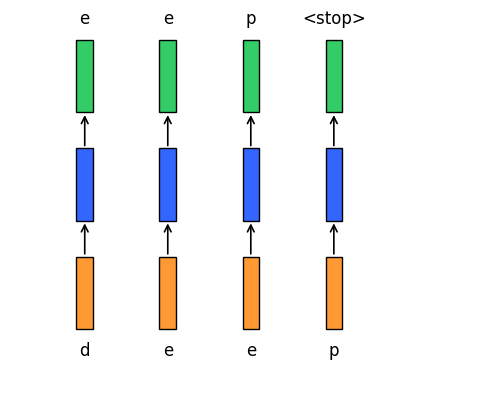

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np

COLOR_IN   = np.array([1.0, 0.6, 0.2])   # orange
COLOR_CELL = np.array([0.2, 0.4, 1.0])   # blue
COLOR_OUT  = np.array([0.2, 0.8, 0.4])   # green

def draw_box(ax, x, y, w, h, color, text, valign="center", pad=0.30):
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor='black')
    ax.add_patch(rect)

    cx = x + w/2

    if valign == "center":
        cy = y + h/2
    elif valign == "top":
        cy = y + h - pad*h
    elif valign == "bottom":
        cy = y + pad*h
    elif valign == "above":
        cy = y + h + pad*h
    elif valign == "below":
        cy = y - pad*h
    else:
        cy = y + h/2

    ax.text(cx, cy, text, ha='center', va='center', fontsize=10)
    return rect

def arrow_down(ax, top_rect, bottom_rect):
    x_mid = top_rect.get_x() + top_rect.get_width()/2
    y_start = top_rect.get_y()
    y_end = bottom_rect.get_y() + bottom_rect.get_height()

    arrow = FancyArrowPatch(
        (x_mid, y_start),
        (x_mid, y_end),
        arrowstyle='<-',
        mutation_scale=12,
        color='black',
        linewidth=1.2
    )
    ax.add_patch(arrow)

def draw_vertical_column(ax, x, inp, out):
    w, h = 0.25, 1.50
    gap = 0.75

    top_y = 0
    top_box = draw_box(ax, x, top_y, w, h, COLOR_OUT, out, valign="above")

    mid_y = top_y - h - gap
    mid_box = draw_box(ax, x, mid_y, w, h, COLOR_CELL, "", valign="center")

    bot_y = mid_y - h - gap
    bot_box = draw_box(ax, x, bot_y, w, h, COLOR_IN, inp, valign="below")

    arrow_down(ax, top_box, mid_box)
    arrow_down(ax, mid_box, bot_box)

def draw_sequence_vertical(inputs, outputs, column_spacing=2.0,
                           save_svg=False, svg_path="diagram.svg"):
    fig, ax = plt.subplots(figsize=(len(inputs)*1.5, 5))

    for i, (inp, out) in enumerate(zip(inputs, outputs)):
        draw_vertical_column(ax, x=i*column_spacing, inp=inp, out=out)

    ax.set_xlim(-1, len(inputs)*column_spacing + 1)
    ax.set_ylim(-6, 2)
    ax.axis('off')

    if save_svg:
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        print(f"Saved SVG to {svg_path}")

    plt.show()

# Example usage
inputs = ["d", "e", "e", "p"]
outputs = ["e", "e", "p", "<stop>"]
column_spacing = 1.25
output_loc = "../M03_lecture02_figures/rnn_sequence.svg"
draw_sequence_vertical(inputs, outputs, column_spacing=column_spacing, save_svg=True, svg_path=output_loc)

Saved SVG to ../M03_lecture02_figures/rnn_sequence-function-labels.svg


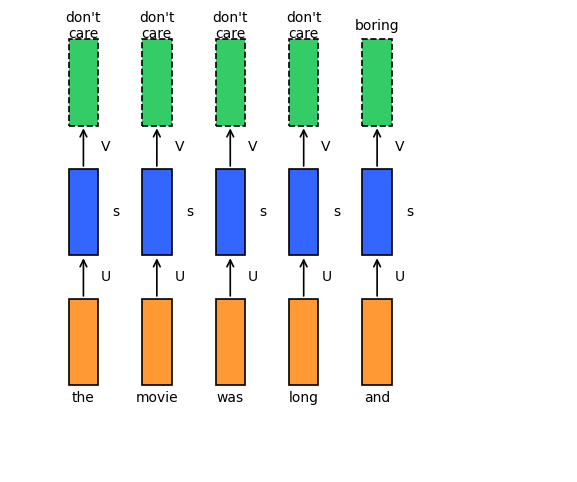

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np

# ---------------------------------------------------------
# COLORS
# ---------------------------------------------------------
COLOR_IN   = np.array([1.0, 0.6, 0.2])   # orange
COLOR_CELL = np.array([0.2, 0.4, 1.0])   # blue
COLOR_OUT  = np.array([0.2, 0.8, 0.4])   # green


# ---------------------------------------------------------
# BOX DRAWING (with inside labels + side labels + edge styles)
# ---------------------------------------------------------
def draw_box(ax, x, y, w, h, color, text,
             valign="center", pad=0.15,
             side_label_left=None, side_label_right=None,
             side_pad=0.25,
             edge_style="solid"):

    rect = Rectangle(
        (x, y), w, h,
        facecolor=color,
        edgecolor='black',
        linestyle=edge_style,
        linewidth=1.2
    )
    ax.add_patch(rect)

    # Inside label
    cx = x + w/2
    if valign == "center":
        cy = y + h/2
    elif valign == "top":
        cy = y + h - pad*h
    elif valign == "bottom":
        cy = y + pad*h
    elif valign == "above":
        cy = y + h + pad*h
    elif valign == "below":
        cy = y - pad*h
    ax.text(cx, cy, text, ha='center', va='center', fontsize=10)

    # LEFT side label
    if side_label_left:
        ax.text(
            x - side_pad, y + h/2,
            side_label_left,
            ha='right', va='center', fontsize=10
        )

    # RIGHT side label
    if side_label_right:
        ax.text(
            x + w + side_pad, y + h/2,
            side_label_right,
            ha='left', va='center', fontsize=10
        )

    return rect

# ---------------------------------------------------------
# ARROWS (with labels)
# ---------------------------------------------------------
def arrow_down(ax, top_rect, bottom_rect,
               label=None, label_side="right", label_pad=0.30):

    x_mid = top_rect.get_x() + top_rect.get_width()/2
    y_start = top_rect.get_y()
    y_end = bottom_rect.get_y() + bottom_rect.get_height()

    # Arrow patch
    arrow = FancyArrowPatch(
        (x_mid, y_start),
        (x_mid, y_end),
        arrowstyle='<-',
        mutation_scale=12,
        color='black',
        linewidth=1.2
    )
    ax.add_patch(arrow)

    # Arrow label
    if label:
        lx = x_mid + (label_pad if label_side == "right" else -label_pad)
        ly = (y_start + y_end) / 2
        ax.text(
            lx, ly, label,
            fontsize=10,
            ha='left' if label_side == "right" else 'right',
            va='center'
        )


# ---------------------------------------------------------
# ONE VERTICAL COLUMN (top → mid → bottom)
# ---------------------------------------------------------
def draw_vertical_column(
    ax, x, inp, out,
    w=0.50, h=1.50, gap=0.75,
    top_edge="solid", mid_edge="solid", bot_edge="solid",
    arrow_labels=("V", "U"),
    top_left_label=None, top_right_label=None,
    mid_left_label=None, mid_right_label=None,
    bot_left_label=None, bot_right_label=None
):

    # TOP (green)
    top_box = draw_box(
        ax, x, 0, w, h, COLOR_OUT, out,
        valign="above",
        side_label_left=top_left_label,
        side_label_right=top_right_label,
        edge_style=top_edge
    )

    # MIDDLE (blue)
    mid_y = 0 - h - gap
    mid_box = draw_box(
        ax, x, mid_y, w, h, COLOR_CELL, "",
        valign="center",
        side_label_left=mid_left_label,
        side_label_right=mid_right_label,
        edge_style=mid_edge
    )

    # BOTTOM (orange)
    bot_y = mid_y - h - gap
    bot_box = draw_box(
        ax, x, bot_y, w, h, COLOR_IN, inp,
        valign="below",
        side_label_left=bot_left_label,
        side_label_right=bot_right_label,
        edge_style=bot_edge
    )

    # Arrows
    arrow_down(ax, top_box, mid_box, label=arrow_labels[0], label_side="right")
    arrow_down(ax, mid_box, bot_box, label=arrow_labels[1], label_side="right")

# ---------------------------------------------------------
# MULTI‑COLUMN SEQUENCE
# ---------------------------------------------------------
def draw_sequence_vertical(inputs, outputs,
                           column_spacing=1.5,
                           save_svg=False, svg_path="diagram.svg",
                           **kwargs):

    fig, ax = plt.subplots(figsize=(len(inputs)*1.2, 6))

    for i, (inp, out) in enumerate(zip(inputs, outputs)):
        draw_vertical_column(
            ax,
            x=i * column_spacing,
            inp=inp,
            out=out,
            **kwargs
        )

    ax.set_xlim(-1, len(inputs)*column_spacing + 1)
    ax.set_ylim(-6, 2)
    ax.axis('off')

    if save_svg:
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        print(f"Saved SVG to {svg_path}")

    plt.show()

inputs = ["the", "movie", "was", "long", "and", ""]
outputs = ["don't\ncare", "don't\ncare", "don't\ncare", "don't\ncare", "boring"]
column_spacing = 1.25
output_loc = "../M03_lecture02_figures/rnn_sequence-function-labels.svg"
draw_sequence_vertical(inputs, outputs,
                       column_spacing=column_spacing,
                       save_svg=True, svg_path=output_loc,
                       top_left_label=None,
                       top_right_label=None,
                       mid_left_label=None,
                       mid_right_label="s",
                       bot_left_label=None,
                       bot_right_label=None,
                       top_edge="dashed",
                       mid_edge="solid",
                       bot_edge="solid",
                       arrow_labels=("V", "U"))